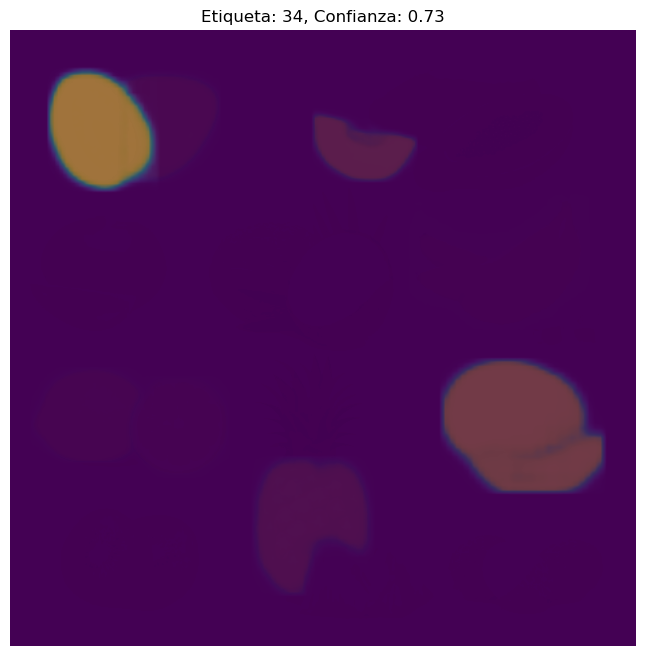

In [45]:
import torch
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Cargar el modelo preentrenado
model = models.detection.maskrcnn_resnet50_fpn(pretrained=True)
model.eval()

# Cargar y transformar la imagen
image_path = "img6.jpg"
image = Image.open(image_path).convert("RGB")
transform = transforms.Compose([
    transforms.ToTensor(),
])
input_tensor = transform(image)
input_batch = input_tensor.unsqueeze(0)  # Batch de tamaño 1

# Realizar la prediccion
with torch.no_grad():
    output = model(input_batch)[0]

# Extraer datos relevantes
scores = output['scores'].numpy()
labels = output['labels'].numpy()
masks = output['masks'].numpy()

# Filtrar por umbral de confianza
confidence_threshold = 0.6
filtered_indices = np.where(scores > confidence_threshold)[0]

# Visualizar los resultados
plt.figure(figsize=(10, 8))
plt.imshow(image)

for i in filtered_indices:
    mask = masks[i, 0]
    plt.imshow(mask, alpha=0.5)
    plt.title(f"Etiqueta: {labels[i]}, Confianza: {scores[i]:.2f}")

plt.axis('off')
plt.show()
